# ProstT5 Probabilistic Folding Drafter Benchmark — AA -> 3Di

This notebook benchmarks the folding-direction probabilistic/HMM-style drafter.

Use the first code cell to choose one mode:

- `dev`: 2 proteins for quick debugging.
- `evaluate`: 100 proteins for the full run.

After the first cell, both modes use the same code path. This keeps dev useful: if dev works, evaluate exercises the same logic on more proteins.


In [23]:
#@title Run mode and benchmark data definition. { display-mode: "form" }

# Change only this value before running:
#   "dev"      -> quick 2-protein run with the same code path
#   "evaluate" -> full 100-protein benchmark
MODE = "dev"

MODE_CONFIGS = {
    "dev": {
        "benchmark_protein_limit": 2,
        "results_subdir": "prostT5_probabilistic_drafter_folding_dev",
    },
    "evaluate": {
        "benchmark_protein_limit": 100,
        "results_subdir": "prostT5_probabilistic_drafter_folding_100",
    },
}

if MODE not in MODE_CONFIGS:
    raise ValueError(f"MODE must be one of {list(MODE_CONFIGS)}, got {MODE!r}")

RUN_CONFIG = MODE_CONFIGS[MODE]

PROSTT5_NAME = "Rostlab/ProstT5_fp16"
RESULTS_SUBDIR = RUN_CONFIG["results_subdir"]
PART2_MSA_CACHE_SUBDIR = "prostT5_benchmarks/msa_hmms"
BENCHMARK_PROTEIN_LIMIT = RUN_CONFIG["benchmark_protein_limit"]
RUN_BENCHMARKS = True

# Same benchmark grid in dev and evaluate. Dev only changes the number of proteins.
K_VALUES = [1, 3, 5, 8, 11, 15]
P_VALUES_OVERRIDE = [1, 2, 3, 4, 5]

USE_FP16 = True
NUM_WARMUP = 0
NUM_REPEATS = 1
HELD_OUT_N = 2
MAX_CONTEXT_P = 5

FAMILY_MSA_MODE = "env"
FAMILY_MSA_MAX_SEQS = 16
FAMILY_MSA_MIN_SEQ_LEN = 40
FAMILY_API_DELAY_S = 2.0


print(f"MODE: {MODE}")
print(f"Benchmark protein limit: {BENCHMARK_PROTEIN_LIMIT}")
print(f"K values: {K_VALUES}")
print(f"Results subdir: {RESULTS_SUBDIR}")
print(f"Part 2 MSA cache: {PART2_MSA_CACHE_SUBDIR}")


MODE: dev
Benchmark protein limit: 2
K values: [1, 3, 5, 8, 11, 15]
Results subdir: prostT5_probabilistic_drafter_folding_dev
Part 2 MSA cache: prostT5_benchmarks/msa_hmms


## Setup

Install/import dependencies, choose the runtime device, and fix random seeds for reproducible stochastic behavior.


### What this cell does

Sets up the notebook runtime.

- Imports Python, PyTorch, Transformers, plotting/data packages, and helper libraries.
- Fixes the random seed for reproducibility.
- Selects the runtime device.
- Requires CUDA/GPU, because this folding benchmark is intended for Colab GPU.


In [24]:
#@title Imports + seed. { display-mode: "form" }

import os, sys, time, statistics, json, importlib.util, subprocess, io, tarfile, zipfile, gc
from pathlib import Path
from collections import defaultdict

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

# Colab often misses these two packages. Install only when needed.
def _ensure_package(import_name: str, pip_name: str | None = None):
    if importlib.util.find_spec(import_name) is None:
        pip_name = pip_name or import_name
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

_ensure_package("sentencepiece")
_ensure_package("accelerate")
_ensure_package("requests")

import numpy as np
import pandas as pd
import torch
import requests
from transformers import T5Tokenizer, AutoModelForSeq2SeqLM, GenerationConfig, PreTrainedModel, T5Config
from transformers.generation.utils import GenerationMixin
from transformers.modeling_outputs import Seq2SeqLMOutput

SEED = 0
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

REQUIRE_CUDA_RUNTIME = True
print(f"torch={torch.__version__}  device={device}  seed={SEED}")
if REQUIRE_CUDA_RUNTIME and device.type != "cuda":
    raise RuntimeError(
        "This notebook is configured for Colab GPU/CUDA. "
        "In Colab, switch Runtime -> Change runtime type -> GPU, then rerun."
    )
if device.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True


torch=2.11.0+cu128  device=cuda:0  seed=0


##### The testing Protein is defined here, change to benchmark when evaluating.

- EMBEDDED_AA_FASTA
- EMBEDDED_3DI_FASTA

### What this cell does

Provides a small local fallback dataset for notebook smoke tests.

- Writes embedded AA and 3Di FASTA files only if the benchmark files are missing.
- Keeps the notebook runnable in Colab after upload or clone.
- Does not change the main benchmark data when the real files exist.


In [25]:
#@title Colab local data setup. { display-mode: "form" }

# No Drive and no manual data copy needed.
# In Colab this cell writes a tiny 10-protein benchmark subset into /content.
# The subset uses the 10 shortest paired AA/3Di examples to keep smoke runs light.

from pathlib import Path

EMBEDDED_AA_FASTA = '>P01542\nTTCCPSIVARSNFNVCRLPGTPEALCATYTGCIIIPGATCPGDYAN\n>P0A7N4\nMAVQQNKPTRSKRGMRRSHDALTAVTSLSVDKTSGEKHLRHHITADGYYRGRKVIAK\n>P02798\nMDPNCSCASDGSCSCAGACKCKQCKCTSCKKSCCSCCPVGCAKCSQGCICKEASDKCSCCA\n>P61583\nMNPSEMQRKGPPQRWCLQVYPTAPKRQRPSRTGHDDDGGFVEKKRGKCGEKQERSDCYCVCVERSRHRRLHFVLY\n>P24311\nMFPLVKSALNRLQVRSIQQTMARQSHQKRTPDFHDKYGNAVLASGATFCIVTWTYVATQVGIEWNLSPVGRVTPKEWRNQ\n>P0A7U3\nMPRSLKKGPFIDLHLLKKVEKAVESGDKKPLRTWSRRSTIFPNMIGLTIAVHNGRQHVPVFVTDEMVGHKLGEFAPTRTY\nRGHAADKKAKKK\n>P63165\nMSDQEAKPSTEDLGDKKEGEYIKLKVIGQDSSEIHFKVKMTTHLKKLKESYCQRQGVPMNSLRFLFEGQRIADNHTPKEL\nGMEEEDVIEVYQEQTGGHSTV\n>P10599\nMVKQIESKTAFQEALDAAGDKLVVVDFSATWCGPCKMIKPFFHSLSEKYSNVIFLEVDVDDCQDVASECEVKCMPTFQFF\nKKGQKVGEFSGANKEKLEATINELV\n>P01308\nMALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPL\nALEGSLQKRGIVEQCCTSICSLYQLENYCN\n>P61769\nMSRSVALAVLALLSLSGLEAIQRTPKIQVYSRHPAENGKSNFLNCYVSGFHPSDIEVDLLKNGERIEKVEHSDLSFSKDW\nSFYLLYYTEFTPTEKDEYACRVNHVTLSQPKIVKWDRDM\n'
EMBEDDED_3DI_FASTA = '>P01542\ndkfaqdpvlvvqlvvcppvvpdsvvscvvsvidddpdddddpsrhd\n>P0A7N4\nddddpddddpvrvcvvcppvddddlpqwdaapqprdidgvpdadpcqddnndrnddd\n>P02798\ndppqfpadpplpdqclqvtnglddprpsrqddnaladdrpqvvcpvhdpdpdrdnhdpvrd\n>P61583\nddpvvvppdddqpwfkfwdaddddppddpddpdpdpppddgdrdrddpddddpdhrifiwtwgcdpvndtdtdgd\n>P24311\ndvvvvvvvvvvvvvvvvvvvvvvvvvpppdqdpcsvcvvvcvvvvvvvvvvvvvcvvppppddpvddcvvppdddppddd\n>P0A7U3\ndaddpvvdfdddpvqvvvlvvclvvvdqdaaedqqqrhfdapscaqhwyqydlppggdtdhdhpvrggpgnnvvrhnddd\npddpppppdddd\n>P63165\nddddddddddddpddddppfwaweweaepvrdtdididgqqdfclvvlvvvcvvvvhdsvqkfkdfpndtgdrrdgcnvv\nvhhhhgyiyidgppppdpppd\n>P10599\ndeaedqepvsvvvvlqvlaqakekewaaappdpqqvvqvvvlvvvcvvcvsyyhyyydcvryvvvcvvvvpddpgkmfmd\ngssdtpdidhtndsvvvvvvvvvsd\n>P01308\ndvpvvvvvvvvvcccvvpdpppppddddddpddppvvvvvcvlvppddppdpdddddddddddddddddddddddddddd\ndpppppppddpppvpsvdpddpvvvvvpsd\n>P61769\ndppvvvvvvvvvvvvvvppddfwdwdwdwewpdqadaqdktkikikiwggpdpdkdkfkdkpndgdppkdkdpwdhdpvr\niiimmimdmdgddppikiwmwmddpvdpdididtydsvd\n'

def _write_text_if_needed(path: Path, text: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists() or path.read_text() != text:
        path.write_text(text)
    print(f"{path}  {path.stat().st_size} bytes")

LOCAL_PROJECT_DIR = Path("/content/Speculative-Decoding-ProstT5")
LOCAL_DATA_DIR = LOCAL_PROJECT_DIR / "prostT5" / "prostT5_benchmarks" / "benchmark_data"

if Path("/content").exists():
    _write_text_if_needed(LOCAL_DATA_DIR / "test_set_AA.fasta", EMBEDDED_AA_FASTA)
    _write_text_if_needed(LOCAL_DATA_DIR / "test_set_3Di.fasta", EMBEDDED_3DI_FASTA)
    print(f"Local Colab data ready: {LOCAL_DATA_DIR}")
else:
    print("Not in Colab; using local repository data if present.")


/content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data/test_set_AA.fasta  941 bytes
/content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data/test_set_3Di.fasta  941 bytes
Local Colab data ready: /content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data


## Configuration

Define model paths, benchmark paths, and benchmark settings. This notebook uses the same benchmark FASTA files as the inverse-folding experiments.


In [26]:
#@title Configuration. { display-mode: "form" }

NOTEBOOK_DIR = Path.cwd().resolve()

def _find_prost_dir(start: Path) -> Path:
    """Find the prostT5 project folder locally or inside a mounted Colab Drive."""
    candidates = []
    candidates.extend([start, *start.parents])
    candidates.extend([
        Path("/content/Speculative-Decoding-ProstT5"),
        Path("/content/drive/MyDrive/Speculative-Decoding-ProstT5"),
        Path("/content/drive/MyDrive/TUM MS Informatics/courses/SoSe 26/PP 1/Speculative-Decoding-ProstT5"),
    ])

    for base in candidates:
        for cand in (base, base / "prostT5"):
            if (cand / "prostT5_benchmarks" / "benchmark_data" / "test_set_AA.fasta").exists():
                return cand.resolve()

    for root in (Path("/content/Speculative-Decoding-ProstT5"), Path("/content"), Path("/content/drive/MyDrive")):
        if root.exists():
            for aa_path in root.glob("**/prostT5_benchmarks/benchmark_data/test_set_AA.fasta"):
                return aa_path.parents[2].resolve()

    raise FileNotFoundError(
        "Could not find prostT5/prostT5_benchmarks/benchmark_data/test_set_AA.fasta. "
        "In Colab, mount Drive or cd into the cloned Speculative-Decoding-ProstT5 repo first."
    )

PROST_DIR = _find_prost_dir(NOTEBOOK_DIR)
DATA_DIR = PROST_DIR / "prostT5_benchmarks" / "benchmark_data"
RESULTS_DIR = PROST_DIR / "results" / RESULTS_SUBDIR
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TEST_AA_FASTA = DATA_DIR / "test_set_AA.fasta"
TEST_3DI_FASTA = DATA_DIR / "test_set_3Di.fasta"

AA_LETTERS = "ACDEFGHIKLMNPQRSTVWY"
HMM_SMOOTHING = 0.5

print(f"Notebook dir: {NOTEBOOK_DIR}")
print(f"Project dir : {PROST_DIR}")
print(f"AA FASTA    : {TEST_AA_FASTA}")
print(f"3Di FASTA   : {TEST_3DI_FASTA}")
print(f"Results dir : {RESULTS_DIR}")
print(f"Protein limit: {BENCHMARK_PROTEIN_LIMIT}")
print(f"K values    : {K_VALUES}")
print(f"Family MSA max homologs: {FAMILY_MSA_MAX_SEQS}")
# print(f"Family generalization train size: {FAMILY_GENERALIZATION_TRAIN_SEQS}")

assert TEST_AA_FASTA.exists(), TEST_AA_FASTA
assert TEST_3DI_FASTA.exists(), TEST_3DI_FASTA


Notebook dir: /content
Project dir : /content/Speculative-Decoding-ProstT5/prostT5
AA FASTA    : /content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data/test_set_AA.fasta
3Di FASTA   : /content/Speculative-Decoding-ProstT5/prostT5/prostT5_benchmarks/benchmark_data/test_set_3Di.fasta
Results dir : /content/Speculative-Decoding-ProstT5/prostT5/results/prostT5_probabilistic_drafter_folding_dev
Protein limit: 2
K values    : [1, 3, 5, 8, 11, 15]
Family MSA max homologs: 16


## Load ProstT5

Load the same full ProstT5 encoder-decoder model, but use the folding prompt `<AA2fold>` so the model generates 3Di tokens from AA input.


In [27]:
#@title Load ProstT5. { display-mode: "form" }

try:
    tokenizer = T5Tokenizer.from_pretrained(PROSTT5_NAME, do_lower_case=False, legacy=True)
except ImportError as exc:
    raise ImportError("T5Tokenizer needs sentencepiece. In Colab run: !pip -q install sentencepiece") from exc

dtype = torch.float16 if (USE_FP16 and device.type == "cuda") else torch.float32


def _load_prostt5(**kwargs):
    try:
        return AutoModelForSeq2SeqLM.from_pretrained(PROSTT5_NAME, dtype=dtype, **kwargs)
    except TypeError:
        # Older transformers versions use torch_dtype instead of dtype.
        return AutoModelForSeq2SeqLM.from_pretrained(PROSTT5_NAME, torch_dtype=dtype, **kwargs)


# This notebook is GPU-only by design. Use device_map on CUDA to avoid an
# unnecessary full CPU copy during model load.
model = _load_prostt5(low_cpu_mem_usage=True, device_map={"": str(device)})
model.eval()
model.config.use_cache = True
model.generation_config.use_cache = True

encoder = model.get_encoder()
DECODER_START_TOKEN_ID = model.config.decoder_start_token_id

print(f"ProstT5 loaded. dtype={dtype} params={sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print(f"Decoder start token ID: {DECODER_START_TOKEN_ID}")


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

ProstT5 loaded. dtype=torch.float16 params=2818.9M
Decoder start token ID: 0


## Load Paired Benchmark FASTA

Parse AA and 3Di FASTA files, match records by UniProt ID, and keep only proteins where AA and 3Di lengths match.


### What this cell does

Loads and pairs the benchmark AA and 3Di sequences.

- Parses `test_set_AA.fasta` and `test_set_3Di.fasta`.
- Matches records by protein ID.
- Keeps only proteins where AA length and 3Di length agree.
- Stores valid pairs in `paired`.


In [28]:
#@title FASTA parsing + paired dataset. { display-mode: "form" }

def parse_fasta(path: Path) -> dict[str, str]:
    records = {}
    cur = None
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                cur = line[1:].split()[0]
                records[cur] = ""
            else:
                records[cur] += line.strip()
    return records

AA_SEQS = parse_fasta(TEST_AA_FASTA)
DI_SEQS = {uid: seq.lower() for uid, seq in parse_fasta(TEST_3DI_FASTA).items()}

paired = {}
for uid in sorted(set(AA_SEQS) & set(DI_SEQS)):
    aa = AA_SEQS[uid].upper()
    di = DI_SEQS[uid].lower()
    if len(aa) != len(di):
        print(f"skip {uid}: length mismatch AA={len(aa)} 3Di={len(di)}")
        continue
    paired[uid] = {"aa": aa, "3di": di, "length": len(aa)}

print(f"Loaded paired benchmark records: {len(paired)}")
print("First records:")
for uid, rec in list(paired.items())[:2]:
    print(f"  {uid}: L={rec['length']} AA={rec['aa'][:12]} 3Di={rec['3di'][:12]}")


Loaded paired benchmark records: 10
First records:
  P01308: L=110 AA=MALWMRLLPLLA 3Di=dvpvvvvvvvvv
  P01542: L=46 AA=TTCCPSIVARSN 3Di=dkfaqdpvlvvq


## Tokenization Helpers

ProstT5 uses task prefixes. For folding we use `<AA2fold>` and generate lowercase 3Di tokens.


### What this cell does

Defines tokenization helpers for the folding direction.

Important objects:

- `_format_aa(seq)`: formats AA input with the `<AA2fold>` task prefix.
- `_decode_3di(token_ids)`: decodes model output back into a compact 3Di string.
- `THREEDI_TOKEN_IDS`: maps each 3Di symbol to its ProstT5 tokenizer ID.

`THREEDI_TOKEN_IDS` is the bridge from the drafter's 20-token 3Di distribution into the full ProstT5 vocabulary.


In [29]:
#@title Folding format helpers. { display-mode: "form" }

def _format_aa(seq: str) -> str:
    return "<AA2fold> " + " ".join(list(seq.upper()))


def _decode_3di(token_ids: torch.Tensor) -> str:
    if token_ids.ndim > 1:
        token_ids = token_ids[0]
    s = tokenizer.decode(token_ids, skip_special_tokens=True)
    return "".join(s.split()).replace("<AA2fold>", "").lower()

THREEDI_ALPHABET = "".join(sorted(set("".join(rec["3di"] for rec in paired.values()))))
THREEDI_TOKEN_IDS = [tokenizer.encode(f" {tok}", add_special_tokens=False)[0] for tok in THREEDI_ALPHABET]
THREEDI_TOKEN_ID_TO_IDX = {tid: i for i, tid in enumerate(THREEDI_TOKEN_IDS)}
THREEDI_IDX_TO_TOKEN_ID = {i: tid for i, tid in enumerate(THREEDI_TOKEN_IDS)}
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_LETTERS)}

print(f"3Di alphabet ({len(THREEDI_ALPHABET)}): {THREEDI_ALPHABET}")
print("First 3Di token IDs:", list(zip(THREEDI_ALPHABET[:8], THREEDI_TOKEN_IDS[:8])))


3Di alphabet (20): acdefghiklmnpqrstvwy
First 3Di token IDs: [('a', 128), ('c', 147), ('d', 135), ('e', 134), ('f', 140), ('g', 130), ('h', 145), ('i', 137)]


## Reference Folding Generation

This is the plain ProstT5 `AA -> 3Di` greedy generation path. It is the verifier/reference output used for correctness checks.

#### Maybe we can cache it so we can reuse the 3Di

In [30]:
#@title Plain enc-dec folding reference. { display-mode: "form" }

@torch.inference_mode()
def generate_folding_reference(aa_seq: str) -> str:
    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    out = None
    try:
        out = model.generate(
            input_ids=enc.input_ids,
            attention_mask=enc.attention_mask,
            max_length=L + 2,
            do_sample=False,
            num_beams=1,
            use_cache=True,
        )
        seq = _decode_3di(out[0])[:L]
        return seq
    finally:
        # Building family HMMs folds many homologs; release transient generate() tensors promptly.
        del enc
        if out is not None:
            del out
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
        elif device.type == "mps" and hasattr(torch, "mps"):
            torch.mps.empty_cache()


## Family-Specific AA-Conditioned 3Di HMM

Build a per-protein drafter from that protein's MMseqs2/ColabFold AA family MSA. Because the API returns AA homologs rather than 3Di labels, the notebook folds a capped number of homolog rows once with ProstT5, projects those pseudo-3Di labels back to query-aligned MSA columns, and estimates draft distributions only from that target family's projected rows.


### What this cell does

Builds the family-specific folding drafter machinery.

Flow:

- Fetch or load an A3M MSA for the query protein.
- Select homolog AA rows from that family.
- Fold homolog AA rows with ProstT5 to obtain pseudo-3Di labels.
- Project pseudo-3Di labels back onto query-aligned MSA columns.
- Count per-position 3Di tokens and convert them into draft logits.

This is not a true Profile HMM over 3Di states. It is a family-local pseudo-3Di drafter.


In [31]:
#@title Family-specific AA-conditioned 3Di HMM from MMseqs2 MSA. { display-mode: "form" }

COLABFOLD_HOST = "https://api.colabfold.com"
COLABFOLD_HEADERS = {
    "User-Agent": "prostt5-folding-hmm-family-notebook/1.0 (educational use)"
}
COLABFOLD_RETRY_STATUS = {429, 500, 502, 503, 504}
THREEDI_SYMBOL_TO_IDX = {tok: i for i, tok in enumerate(THREEDI_ALPHABET)}


def _log_normalize(x: np.ndarray, axis=None) -> np.ndarray:
    m = np.max(x, axis=axis, keepdims=True)
    return x - (m + np.log(np.sum(np.exp(x - m), axis=axis, keepdims=True)))


def _cf_request(method: str, url: str, *, max_retries: int = 8,
                base_backoff: float = 10.0, max_backoff: float = 120.0,
                **kwargs) -> requests.Response:
    """ColabFold API request with quiet exponential backoff."""
    kwargs.setdefault("headers", COLABFOLD_HEADERS)
    resp = None
    for attempt in range(max_retries):
        resp = requests.request(method, url, **kwargs)
        if resp.status_code not in COLABFOLD_RETRY_STATUS:
            resp.raise_for_status()
            return resp
        retry_after = resp.headers.get("Retry-After")
        try:
            wait = float(retry_after) if retry_after is not None else None
        except ValueError:
            wait = None
        if wait is None:
            wait = min(base_backoff * (2 ** attempt), max_backoff)
        time.sleep(wait)
    resp.raise_for_status()
    return resp


def _fetch_msa_colabfold(aa_seq: str, cache_path: Path,
                         mode: str = FAMILY_MSA_MODE,
                         poll_interval: float = 5.0,
                         max_wait_s: float = 600.0) -> str | None:
    """Fetch/cache an A3M MSA for one protein family using the ColabFold MMseqs2 API."""
    if cache_path.exists():
        return cache_path.read_text()

    try:
        submit_attempts = 0
        while True:
            resp = _cf_request(
                "POST",
                f"{COLABFOLD_HOST}/ticket/msa",
                data={"q": f">query\n{aa_seq}\n", "mode": mode},
                timeout=30,
            )
            sub = resp.json()
            status = sub.get("status", "")
            if status != "RATELIMIT":
                break
            submit_attempts += 1
            if submit_attempts > 8:
                print("    MSA API rate-limited after retries; using uniform drafter")
                return None
            time.sleep(min(10.0 * (2 ** (submit_attempts - 1)), 120.0))

        job_id = sub.get("id")
        if not job_id:
            print("    MSA API returned no job id; using uniform drafter")
            return None

        waited = 0.0
        while status != "COMPLETE":
            if status in ("ERROR", "MAINTENANCE"):
                print(f"    MSA API status={status}; using uniform drafter")
                return None
            if waited >= max_wait_s:
                print("    MSA API timed out; using uniform drafter")
                return None
            time.sleep(poll_interval)
            waited += poll_interval
            sr = _cf_request("GET", f"{COLABFOLD_HOST}/ticket/{job_id}", timeout=15)
            status = sr.json().get("status", "")

        dl = _cf_request("GET", f"{COLABFOLD_HOST}/result/download/{job_id}", timeout=120)
        data = dl.content
        a3m_parts = []
        if data[:2] == b"PK":
            with zipfile.ZipFile(io.BytesIO(data)) as zf:
                for name in zf.namelist():
                    if name.endswith(".a3m"):
                        a3m_parts.append(zf.read(name).decode("utf-8", "ignore"))
        elif data[:2] == b"\x1f\x8b":
            with tarfile.open(fileobj=io.BytesIO(data)) as tf:
                for member in tf.getmembers():
                    if member.name.endswith(".a3m"):
                        fh = tf.extractfile(member)
                        if fh is not None:
                            a3m_parts.append(fh.read().decode("utf-8", "ignore"))
        else:
            txt = data.decode("utf-8", "ignore")
            if txt.lstrip().startswith(">"):
                a3m_parts.append(txt)

        a3m_text = "\n".join(part.strip() for part in a3m_parts if part.strip()) or None
        if a3m_text is None:
            print("    MSA API result had no A3M; using uniform drafter")
            return None
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        cache_path.write_text(a3m_text)
        return a3m_text
    except Exception as exc:
        print(f"    MSA fetch failed ({type(exc).__name__}); using uniform drafter")
        return None


def _parse_a3m_records(a3m: str) -> list[tuple[str, str]]:
    records = []
    name = None
    chunks = []
    for raw in a3m.splitlines():
        line = raw.replace("\x00", "").strip()
        if not line:
            continue
        if line.startswith(">"):
            if name is not None:
                records.append((name, "".join(chunks)))
            name = line[1:].split()[0] or f"seq{len(records)}"
            chunks = []
        else:
            chunks.append(line)
    if name is not None:
        records.append((name, "".join(chunks)))
    return records


def _strip_a3m_insertions(seq: str) -> str:
    return "".join(c.upper() for c in seq if not c.islower() and c not in ".*")


def _ungap_aa(seq: str) -> str:
    return "".join(c for c in seq.upper() if c in AA_TO_IDX)


def _project_homolog_3di_to_query(query_aln: str, homolog_aln: str, homolog_3di: str) -> list[str | None]:
    L = sum(1 for c in query_aln if c != "-")
    projected = [None] * L
    q_pos = 0
    h_pos = 0
    width = min(len(query_aln), len(homolog_aln))
    for i in range(width):
        q_char = query_aln[i]
        h_char = homolog_aln[i]
        h_token = None
        if h_char != "-":
            if h_pos < len(homolog_3di):
                h_token = homolog_3di[h_pos]
            h_pos += 1
        if q_char != "-":
            if h_token in THREEDI_SYMBOL_TO_IDX:
                projected[q_pos] = h_token
            q_pos += 1
    return projected


class FamilyFoldingHMMDrafter:
    """Protein-family-specific AA->3Di drafter built from one target's MSA family.

    The ColabFold API supplies only AA homologs. To keep the drafter family-local,
    homolog AA rows are folded once with ProstT5, projected to query MSA columns,
    and counted as pseudo-labeled family examples. No unrelated benchmark proteins
    are used for this target's HMM.
    """

    def __init__(self, uid: str, aa_seq: str, a3m: str | None,
                 max_family_seqs: int = FAMILY_MSA_MAX_SEQS,
                 smoothing: float = HMM_SMOOTHING):
        self.uid = uid
        self.aa_seq = aa_seq
        self.smoothing = smoothing
        self.max_family_seqs = max_family_seqs
        self.n_family_seqs = 0
        self.n_projected_seqs = 0
        self.context_counts = defaultdict(lambda: np.zeros(len(THREEDI_ALPHABET), dtype=np.float32))
        self.logits = self._build_logits(a3m)

    def _candidate_family_rows(self, a3m: str | None) -> list[tuple[str, str, str]]:
        if not a3m:
            return []
        records = _parse_a3m_records(a3m)
        if len(records) < 2:
            return []
        query_aln = _strip_a3m_insertions(records[0][1])
        rows = []
        seen = set()
        for name, raw_aln in records[1:]:
            aln = _strip_a3m_insertions(raw_aln)
            aa = _ungap_aa(aln)
            if len(aa) < FAMILY_MSA_MIN_SEQ_LEN or aa in seen:
                continue
            seen.add(aa)
            rows.append((name, query_aln, aln))
            if len(rows) >= self.max_family_seqs:
                break
        return rows

    def _build_logits(self, a3m: str | None) -> np.ndarray:
        L = len(self.aa_seq)
        S = len(THREEDI_ALPHABET)
        counts = np.full((L, S), self.smoothing, dtype=np.float32)
        rows = self._candidate_family_rows(a3m)
        self.n_family_seqs = len(rows)

        for _, query_aln, homolog_aln in rows:
            homolog_aa = _ungap_aa(homolog_aln)
            if not homolog_aa:
                continue
            homolog_3di = generate_folding_reference(homolog_aa)
            projected = _project_homolog_3di_to_query(query_aln, homolog_aln, homolog_3di)
            if len(projected) != L:
                continue
            observed = [(pos, tok) for pos, tok in enumerate(projected) if tok in THREEDI_SYMBOL_TO_IDX]
            if not observed:
                continue
            self.n_projected_seqs += 1
            for pos, tok in observed:
                counts[pos, THREEDI_SYMBOL_TO_IDX[tok]] += np.float32(1.0)
            for pos, tok in observed:
                for ctx_len in range(min(MAX_CONTEXT_P, pos), -1, -1):
                    ctx_start = pos - ctx_len
                    ctx = projected[ctx_start:pos]
                    if any(c not in THREEDI_SYMBOL_TO_IDX for c in ctx):
                        continue
                    self.context_counts[(pos, tuple(ctx))][THREEDI_SYMBOL_TO_IDX[tok]] += np.float32(1.0)

        return np.log(counts / counts.sum(axis=1, keepdims=True)).astype(np.float32)

    def get_draft_logits(self, pos: int, prefix=None, K: int | None = None):
        if pos >= self.logits.shape[0]:
            return self.logits[:0]
        if K is None:
            return self.logits[pos:]
        return self.logits[pos:pos + K]

    def emission_for_prefix(self, prefix_symbols: list[str], max_p: int) -> np.ndarray:
        pos = len(prefix_symbols)
        if pos >= self.logits.shape[0]:
            return np.full(len(THREEDI_ALPHABET), -np.log(len(THREEDI_ALPHABET)), dtype=np.float32)
        available = min(max_p, len(prefix_symbols))
        for ctx_len in range(available, -1, -1):
            ctx = tuple(prefix_symbols[-ctx_len:]) if ctx_len > 0 else tuple()
            key = (pos, ctx)
            if key in self.context_counts:
                counts = self.context_counts[key] + self.smoothing
                return np.log(counts / counts.sum()).astype(np.float32)
        return self.logits[pos]


class PrefixAwareFoldingHMMDrafter:
    """Prefix-aware view over a family-specific folding HMM drafter."""

    def __init__(self, base_drafter: FamilyFoldingHMMDrafter, max_p: int = 5):
        self.base_drafter = base_drafter
        self.uid = base_drafter.uid
        self.aa_seq = base_drafter.aa_seq
        self.max_p = max_p
        self.n_family_seqs = base_drafter.n_family_seqs
        self.n_projected_seqs = base_drafter.n_projected_seqs

    def emission_for_prefix(self, prefix_symbols: list[str]) -> np.ndarray:
        return self.base_drafter.emission_for_prefix(prefix_symbols, self.max_p)


def build_family_folding_drafter(uid: str, aa_seq: str, msa_dir: Path) -> FamilyFoldingHMMDrafter:
    cache_path = msa_dir / f"{uid}.a3m"
    cache_hit = cache_path.exists()
    a3m = _fetch_msa_colabfold(aa_seq, cache_path=cache_path)
    if a3m is not None and not cache_hit and FAMILY_API_DELAY_S > 0:
        time.sleep(FAMILY_API_DELAY_S)
    return FamilyFoldingHMMDrafter(uid, aa_seq, a3m)

print("Family-specific folding HMM helpers loaded (MMseqs2 MSA -> pseudo-3Di family counts).")


Family-specific folding HMM helpers loaded (MMseqs2 MSA -> pseudo-3Di family counts).


## Build Family HMM Drafters

Build one family-specific HMM drafter per benchmark protein. Each drafter uses only its own cached MSA family; if no usable homolog rows are available, it falls back to a uniform drafter for that protein.


### What this cell does

Builds the static drafter for each benchmark protein.

- One `FamilyFoldingHMMDrafter` is built per query protein.
- Each drafter uses only that protein's MSA family.
- The drafter returns position-specific 3Di distributions.
- It does not look back at the generated prefix.


In [19]:
#@title Build family-specific folding HMM drafters. { display-mode: "form" }

FAMILY_MSA_DIR = PROST_DIR / PART2_MSA_CACHE_SUBDIR
FAMILY_MSA_DIR.mkdir(parents=True, exist_ok=True)

hmm_drafters = {}
drafter_items = sorted(paired.items(), key=lambda kv: kv[1]["length"])
if BENCHMARK_PROTEIN_LIMIT is not None:
    drafter_items = drafter_items[:max(BENCHMARK_PROTEIN_LIMIT, HELD_OUT_N)]

print(f"Building family HMM drafters for {len(drafter_items)} proteins...")
for i, (uid, rec) in enumerate(drafter_items, start=1):
    d = build_family_folding_drafter(uid, rec["aa"], FAMILY_MSA_DIR)
    hmm_drafters[uid] = d
    print(f"  [{i}/{len(drafter_items)}] {uid}: homologs={d.n_family_seqs}, projected={d.n_projected_seqs}")
    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    elif device.type == "mps" and hasattr(torch, "mps"):
        torch.mps.empty_cache()

n_family = sum(d.n_projected_seqs > 0 for d in hmm_drafters.values())
print(f"Family HMM coverage: {n_family}/{len(hmm_drafters)} with projected homolog pseudo-labels")


Building family HMM drafters for 2 proteins...
  [1/2] P01542: homologs=16, projected=16
  [2/2] P0A7N4: homologs=16, projected=16
Family HMM coverage: 2/2 with projected homolog pseudo-labels


## Prefix-Aware Family HMM

The prefix-aware view reuses the same family-specific projected pseudo-3Di rows, but conditions the next-token distribution on previously accepted 3Di tokens up to context length `p`.


### What this cell does

Defines the prefix-aware view of the family drafter.

- Reuses the same family pseudo-3Di counts.
- Conditions on recent accepted 3Di prefix tokens.
- Falls back to the static position-wise distribution when a prefix context is missing.


In [20]:
#@title Prefix-aware context HMM for AA -> 3Di. { display-mode: "form" }

# PrefixAwareFoldingHMMDrafter is defined with the family-specific HMM helpers.
# It reuses each protein's MSA-derived pseudo-3Di family counts and conditions on
# the accepted 3Di prefix up to max_p tokens.
print("Prefix-aware family HMM drafter class ready.")


Prefix-aware family HMM drafter class ready.


## Build Prefix-Aware Family Drafters

Build lightweight prefix-aware views for `p = 1..5` from the already-built family HMM drafters. This reuses the cached MSA-derived counts and does not call the API again.


### What this cell does

Builds prefix-aware drafters for multiple context lengths.

Parameter:

- `p`: number of previous generated 3Di tokens used as context.

The notebook builds `p = 1, 2, 3, 4, 5` views for each static family drafter.


In [21]:
#@title Build prefix-aware family HMM drafters, p=1..5. { display-mode: "form" }

P_VALUES = P_VALUES_OVERRIDE
prefix_hmm_drafters = {p_val: {} for p_val in P_VALUES}

for p_val in P_VALUES:
    for uid, base_drafter in hmm_drafters.items():
        prefix_hmm_drafters[p_val][uid] = PrefixAwareFoldingHMMDrafter(base_drafter, max_p=p_val)

print(
    f"Prefix-aware family HMM drafters ready: "
    f"{len(hmm_drafters)} proteins x {len(P_VALUES)} context lengths"
)


Prefix-aware family HMM drafters ready: 2 proteins x 5 context lengths


## HuggingFace Assistant Model Wrapper

Wrap the folding HMM drafter as a `PreTrainedModel` so it can be passed to `model.generate(..., assistant_model=...)`.


### What this cell does

Wraps the static family drafter as a HuggingFace assistant model.

- Converts 20-dimensional 3Di logits into full ProstT5 vocabulary logits.
- Uses `THREEDI_TOKEN_IDS` to place logits in the correct vocabulary positions.
- Enables `model.generate(..., assistant_model=hmm_assistant)`.


In [22]:
#@title Folding HMM assistant_model wrapper. { display-mode: "form" }

class FoldingHMMAssistantModel(PreTrainedModel, GenerationMixin):
    """HF-compatible assistant for AA -> 3Di HMM drafting."""

    config_class = T5Config

    def __init__(self, config, prostt5_encoder, three_di_token_ids, device):
        super().__init__(config)
        self._encoder = prostt5_encoder
        self._di_ids = torch.tensor(three_di_token_ids, device=device, dtype=torch.long)
        self._device = device
        self.config.is_encoder_decoder = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=5,
            num_assistant_tokens_schedule="constant",
            do_sample=False,
            max_length=3000,
        )
        self._active = None

    def set_drafter(self, drafter):
        self._active = drafter

    def get_encoder(self):
        return self._encoder

    def _validate_model_kwargs(self, model_kwargs):
        return

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None, **kwargs):
        return {"decoder_input_ids": decoder_input_ids, "encoder_outputs": encoder_outputs}

    def forward(self, decoder_input_ids=None, encoder_outputs=None, **kwargs):
        seq_len = decoder_input_ids.shape[1]
        vocab = self.config.vocab_size
        logits = torch.full((1, seq_len, vocab), -1e4, device=decoder_input_ids.device)

        if self._active is not None and seq_len > 0:
            rows = self._active.get_draft_logits(0, K=seq_len)
            if rows.shape[0] > 0:
                rows = torch.from_numpy(rows).to(self._device, dtype=logits.dtype)
                logits[0, :rows.shape[0], self._di_ids] = rows

        return Seq2SeqLMOutput(logits=logits)


hmm_assistant = FoldingHMMAssistantModel(
    config=model.config,
    prostt5_encoder=encoder,
    three_di_token_ids=THREEDI_TOKEN_IDS,
    device=device,
).to(device).eval()

print("Folding HMM assistant created.")

Folding HMM assistant created.


## Prefix-Aware Assistant Model

This assistant reads the current decoder prefix, converts previous generated token IDs back to 3Di symbols, and asks the active prefix-aware drafter for the next-token distribution.


### What this cell does

Wraps the prefix-aware family drafter as a HuggingFace assistant model.

- Reads the current decoder prefix.
- Converts generated token IDs back to 3Di symbols.
- Requests a prefix-conditioned next-token distribution from the active drafter.


In [32]:
#@title Prefix-aware folding HMM assistant_model wrapper. { display-mode: "form" }

TOKEN_ID_TO_3DI = {tid: tok for tok, tid in zip(THREEDI_ALPHABET, THREEDI_TOKEN_IDS)}

class PrefixAwareFoldingHMMAssistantModel(PreTrainedModel, GenerationMixin):
    """HF-compatible assistant for prefix-aware AA -> 3Di HMM drafting."""

    config_class = T5Config

    def __init__(self, config, prostt5_encoder, three_di_token_ids, device):
        super().__init__(config)
        self._encoder = prostt5_encoder
        self._di_ids = torch.tensor(three_di_token_ids, device=device, dtype=torch.long)
        self._device = device
        self.config.is_encoder_decoder = True
        self.config.decoder_start_token_id = config.decoder_start_token_id
        self.generation_config = GenerationConfig(
            num_assistant_tokens=5,
            num_assistant_tokens_schedule="constant",
            do_sample=False,
            max_length=3000,
        )
        self._active = None

    def set_drafter(self, drafter):
        self._active = drafter

    def get_encoder(self):
        return self._encoder

    def _validate_model_kwargs(self, model_kwargs):
        return

    def prepare_inputs_for_generation(self, decoder_input_ids, encoder_outputs=None, **kwargs):
        return {"decoder_input_ids": decoder_input_ids, "encoder_outputs": encoder_outputs}

    def forward(self, decoder_input_ids=None, encoder_outputs=None, **kwargs):
        seq_len = decoder_input_ids.shape[1]
        vocab = self.config.vocab_size
        logits = torch.full((1, seq_len, vocab), -1e4, device=decoder_input_ids.device)

        if self._active is None or seq_len == 0:
            return Seq2SeqLMOutput(logits=logits)

        prefix_symbols = []
        decoded_ids = decoder_input_ids[0, 1:].tolist()

        for pos in range(seq_len):
            row = self._active.emission_for_prefix(prefix_symbols)
            row = torch.from_numpy(row).to(self._device, dtype=logits.dtype)
            logits[0, pos, self._di_ids] = row

            if pos < len(decoded_ids):
                token_id = decoded_ids[pos]
                if token_id in TOKEN_ID_TO_3DI:
                    prefix_symbols.append(TOKEN_ID_TO_3DI[token_id])

        return Seq2SeqLMOutput(logits=logits)


prefix_hmm_assistant = PrefixAwareFoldingHMMAssistantModel(
    config=model.config,
    prostt5_encoder=encoder,
    three_di_token_ids=THREEDI_TOKEN_IDS,
    device=device,
).to(device).eval()

print("Prefix-aware folding HMM assistant created.")

Prefix-aware folding HMM assistant created.


### What this cell does

Checks whether static HMM assisted generation matches plain ProstT5 greedy folding.

- The drafter may be wrong.
- The final verified output should still match the verifier in strict greedy speculative decoding.
- Mismatches suggest assistant alignment/configuration issues.


### What this cell does

Checks whether prefix-aware assisted generation matches plain ProstT5 greedy folding.

Parameters tested:

- `p`: prefix context length.
- `K`: draft length.

The output reports how many `(p, K)` configurations are exactly correct.


## Timing Helpers

Measure plain enc-dec folding and HMM-assisted folding with the same warmup/repeat pattern as the inverse-folding notebook.


### What this cell does

Defines benchmark timing functions for plain enc-dec and static HMM assisted folding.

Metrics collected:

- `wall_s`: runtime in seconds.
- `peak_vram_gb`: peak GPU memory.
- generated 3Di output for exact-match comparison.


In [33]:
#@title Timing helpers. { display-mode: "form" }

def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def _reset_peak_mem():
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
    elif device.type == "mps":
        torch.mps.empty_cache()


def _peak_mem_gb() -> float:
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated(device) / 1e9
    elif device.type == "mps":
        return torch.mps.current_allocated_memory() / 1e9
    return 0.0


@torch.inference_mode()
def time_encdec_folding(aa_seq: str):
    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    gen_kwargs = dict(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        use_cache=False,
    )
    for _ in range(NUM_WARMUP):
        model.generate(**gen_kwargs)
    _sync()
    times = []
    _reset_peak_mem()
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        out = model.generate(**gen_kwargs)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), _decode_3di(out[0])[:L], _peak_mem_gb()


@torch.inference_mode()
def time_hmm_assisted_folding(uid: str, aa_seq: str, K: int):
    drafter = hmm_drafters[uid]
    hmm_assistant.set_drafter(drafter)
    hmm_assistant.generation_config.num_assistant_tokens = float(K)
    hmm_assistant.generation_config.num_assistant_tokens_schedule = "constant"
    hmm_assistant.generation_config.do_sample = False

    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    gen_kwargs = dict(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        use_cache=True,
        assistant_model=hmm_assistant,
    )
    for _ in range(NUM_WARMUP):
        model.generate(**gen_kwargs)
    _sync()
    times = []
    _reset_peak_mem()
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        out = model.generate(**gen_kwargs)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), _decode_3di(out[0])[:L], _peak_mem_gb()

print("Timing helpers ready.")


Timing helpers ready.


## Prefix-Aware Timing Helper

Time the prefix-aware assistant for a selected context length `p` and draft length `K`.


### What this cell does

Defines the timing function for prefix-aware assisted folding.

Inputs:

- protein ID.
- AA sequence.
- prefix context length `p_val`.
- draft length `K`.


In [34]:
#@title Prefix-aware timing helper. { display-mode: "form" }

@torch.inference_mode()
def time_prefix_hmm_assisted_folding(uid: str, aa_seq: str, p_val: int, K: int):
    drafter = prefix_hmm_drafters[p_val][uid]
    prefix_hmm_assistant.set_drafter(drafter)
    prefix_hmm_assistant.generation_config.num_assistant_tokens = float(K)
    prefix_hmm_assistant.generation_config.num_assistant_tokens_schedule = "constant"
    prefix_hmm_assistant.generation_config.do_sample = False

    L = len(aa_seq)
    enc = tokenizer([_format_aa(aa_seq)], add_special_tokens=True, return_tensors="pt").to(device)
    gen_kwargs = dict(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        do_sample=False,
        num_beams=1,
        use_cache=True,
        assistant_model=prefix_hmm_assistant,
    )
    for _ in range(NUM_WARMUP):
        model.generate(**gen_kwargs)
    _sync()
    times = []
    _reset_peak_mem()
    for _ in range(NUM_REPEATS):
        _sync()
        t0 = time.perf_counter()
        out = model.generate(**gen_kwargs)
        _sync()
        times.append(time.perf_counter() - t0)
    return statistics.median(times), _decode_3di(out[0])[:L], _peak_mem_gb()

print("Prefix-aware timing helper ready.")


Prefix-aware timing helper ready.


## Mode-Selected Benchmark Settings

The first code cell selects `MODE` and defines `BENCHMARK_PROTEIN_LIMIT`, `K_VALUES`, and `RESULTS_SUBDIR`. From this point onward, dev and evaluate use the same benchmark code path.


## Single Benchmark Flow

The notebook now runs one benchmark flow and then aggregates results.

Parameters come from the first cell:

- `MODE`: `dev` or `evaluate`.
- `BENCHMARK_PROTEIN_LIMIT`: 2 for dev, 100 for evaluate.
- `K_VALUES`: `[1, 3, 5, 8, 11, 15]`.
- `P_VALUES_OVERRIDE`: prefix context lengths for PA-HMM.
- `RESULTS_SUBDIR`: output folder for this mode.


## Benchmark Loop

Run the same benchmark proteins for plain ProstT5 folding and HMM-assisted folding over multiple K values.


### What this cell does

Runs the static HMM benchmark.

For each protein:

- time plain ProstT5 folding.
- time HMM-assisted folding for each `K`.
- record speedup, exact match, peak vRAM, and family coverage.


In [35]:
#@title Main folding HMM benchmark loop. { display-mode: "form" }

if not RUN_BENCHMARKS:
    print("Skipping static HMM timing benchmark (RUN_BENCHMARKS=False).")
    results_df = pd.DataFrame()
else:

    rows = []
    bench_exact = 0
    bench_total = 0
    proteins = sorted(paired.items(), key=lambda kv: kv[1]["length"])
    if BENCHMARK_PROTEIN_LIMIT is not None:
        proteins = proteins[:BENCHMARK_PROTEIN_LIMIT]

    for idx, (uid, rec) in enumerate(proteins, start=1):
        aa = rec["aa"]
        L = rec["length"]

        t_ref, seq_ref, mem_ref = time_encdec_folding(aa)
        rows.append(dict(
            protein_id=uid,
            length=L,
            pipeline="enc_dec_folding",
            K=0,
            wall_s=t_ref,
            speedup=1.0,
            peak_vram_gb=mem_ref,
            exact_match=True,
            family_homologs=hmm_drafters[uid].n_family_seqs,
            family_projected=hmm_drafters[uid].n_projected_seqs,
        ))

        protein_exact = 0
        protein_speedups = []
        for K in K_VALUES:
            t_hmm, seq_hmm, mem_hmm = time_hmm_assisted_folding(uid, aa, K=K)
            exact = seq_hmm == seq_ref
            speedup = t_ref / t_hmm if t_hmm > 0 else float("nan")
            bench_total += 1
            bench_exact += int(exact)
            protein_exact += int(exact)
            protein_speedups.append(speedup)
            rows.append(dict(
                protein_id=uid,
                length=L,
                pipeline="hmm_assisted_folding",
                K=K,
                wall_s=t_hmm,
                speedup=speedup,
                peak_vram_gb=mem_hmm,
                exact_match=exact,
                family_homologs=hmm_drafters[uid].n_family_seqs,
                family_projected=hmm_drafters[uid].n_projected_seqs,
            ))
        print(
            f"[{idx}/{len(proteins)}] {uid} L={L}: "
            f"exact={protein_exact}/{len(K_VALUES)}, "
            f"median_speedup={np.nanmedian(protein_speedups):.2f}x, "
            f"family_projected={hmm_drafters[uid].n_projected_seqs}"
        )

    results_df = pd.DataFrame(rows)
    results_path = RESULTS_DIR / "folding_hmm_results.csv"
    results_df.to_csv(results_path, index=False)
    print(f"HMM-assisted bit-exact: {bench_exact}/{bench_total} ({bench_exact / bench_total:.1%})")
    print(f"Saved {len(results_df)} rows to {results_path}")
    results_df.head()


[transformers] Passing `generation_config` together with generation-related arguments=({'min_new_tokens', 'use_cache', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more inform

[1/2] P01542 L=46: exact=6/6, median_speedup=1.17x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[2/2] P0A7N4 L=57: exact=6/6, median_speedup=2.33x, family_projected=16
HMM-assisted bit-exact: 12/12 (100.0%)
Saved 14 rows to /content/Speculative-Decoding-ProstT5/prostT5/results/prostT5_probabilistic_drafter_folding_dev/folding_hmm_results.csv


## Prefix-Aware Benchmark Loop

Benchmark prefix-aware folding HMM drafters for `p = 1..5` and `K = 1, 3, 5, 8` using the same proteins.


### What this cell does

Runs the prefix-aware HMM benchmark.

For each protein, it tests all combinations of:

- `p` in `P_VALUES`.
- `K` in `K_VALUES`.

This is where outputs such as `prefix_exact=8/20` are produced.


In [36]:
#@title Main prefix-aware folding HMM benchmark loop. { display-mode: "form" }

if not RUN_BENCHMARKS:
    print("Skipping prefix-aware HMM timing benchmark (RUN_BENCHMARKS=False).")
    prefix_results_df = pd.DataFrame()
else:

    prefix_rows = []
    prefix_bench_exact = 0
    prefix_bench_total = 0
    proteins = sorted(paired.items(), key=lambda kv: kv[1]["length"])
    if BENCHMARK_PROTEIN_LIMIT is not None:
        proteins = proteins[:BENCHMARK_PROTEIN_LIMIT]
    ref_cache = {}

    for idx, (uid, rec) in enumerate(proteins, start=1):
        aa = rec["aa"]
        L = rec["length"]

        if uid not in ref_cache:
            t_ref, seq_ref, mem_ref = time_encdec_folding(aa)
            ref_cache[uid] = (t_ref, seq_ref, mem_ref)
        else:
            t_ref, seq_ref, mem_ref = ref_cache[uid]

        protein_exact = 0
        protein_total = 0
        protein_speedups = []
        for p_val in P_VALUES:
            for K in K_VALUES:
                t_hmm, seq_hmm, mem_hmm = time_prefix_hmm_assisted_folding(uid, aa, p_val=p_val, K=K)
                exact = seq_hmm == seq_ref
                speedup = t_ref / t_hmm if t_hmm > 0 else float("nan")
                prefix_bench_total += 1
                prefix_bench_exact += int(exact)
                protein_total += 1
                protein_exact += int(exact)
                protein_speedups.append(speedup)
                prefix_rows.append(dict(
                    protein_id=uid,
                    length=L,
                    pipeline="prefix_hmm_assisted_folding",
                    p=p_val,
                    K=K,
                    wall_s=t_hmm,
                    speedup=speedup,
                    peak_vram_gb=mem_hmm,
                    exact_match=exact,
                    family_homologs=hmm_drafters[uid].n_family_seqs,
                    family_projected=hmm_drafters[uid].n_projected_seqs,
                ))
        print(
            f"[{idx}/{len(proteins)}] {uid} L={L}: "
            f"prefix_exact={protein_exact}/{protein_total}, "
            f"median_speedup={np.nanmedian(protein_speedups):.2f}x, "
            f"family_projected={hmm_drafters[uid].n_projected_seqs}"
        )

    prefix_results_df = pd.DataFrame(prefix_rows)
    prefix_results_path = RESULTS_DIR / "folding_prefix_hmm_results.csv"
    prefix_results_df.to_csv(prefix_results_path, index=False)
    print(f"Prefix-aware HMM bit-exact: {prefix_bench_exact}/{prefix_bench_total} ({prefix_bench_exact / prefix_bench_total:.1%})")
    print(f"Saved {len(prefix_results_df)} rows to {prefix_results_path}")
    prefix_results_df.head()


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[1/2] P01542 L=46: prefix_exact=10/30, median_speedup=1.13x, family_projected=16


[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=1) and `max_length`(=3000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

[2/2] P0A7N4 L=57: prefix_exact=30/30, median_speedup=1.93x, family_projected=16
Prefix-aware HMM bit-exact: 40/60 (66.7%)
Saved 60 rows to /content/Speculative-Decoding-ProstT5/prostT5/results/prostT5_probabilistic_drafter_folding_dev/folding_prefix_hmm_results.csv


## Aggregate Results

Summarize speedup and memory behavior for the folding HMM drafter.


### What this cell does

Summarizes the static HMM benchmark table.

Grouped by:

- pipeline.
- draft length `K`.

Saved as `folding_hmm_summary.csv`.


In [37]:
#@title Aggregate folding HMM results. { display-mode: "form" }

summary = (
    results_df
    .groupby(["pipeline", "K"], dropna=False)
    .agg(
        n=("protein_id", "count"),
        median_wall_s=("wall_s", "median"),
        median_speedup=("speedup", "median"),
        median_peak_vram_gb=("peak_vram_gb", "median"),
        exact_match_rate=("exact_match", "mean"),
    )
    .reset_index()
)
summary_path = RESULTS_DIR / "folding_hmm_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"Saved summary to {summary_path}")
summary


Saved summary to /content/Speculative-Decoding-ProstT5/prostT5/results/prostT5_probabilistic_drafter_folding_dev/folding_hmm_summary.csv


,pipeline,K,n,median_wall_s,median_speedup,median_peak_vram_gb,exact_match_rate
0,enc_dec_folding,0,2,2.117132,1.000000,10.484978,1.0
1,hmm_assisted_folding,1,2,1.689278,1.275700,10.520870,1.0
2,hmm_assisted_folding,3,2,1.348520,1.737097,10.520932,1.0
3,hmm_assisted_folding,5,2,1.511809,1.615396,10.520911,1.0
4,hmm_assisted_folding,8,2,1.289554,1.730656,10.521309,1.0
5,hmm_assisted_folding,11,2,1.228930,1.848214,10.521618,1.0
6,hmm_assisted_folding,15,2,1.126641,2.212384,10.521806,1.0


## Prefix-Aware Aggregate Results

Summarize the effect of previous-token context length `p` on folding assisted generation.


### What this cell does

Summarizes prefix-aware benchmark results.

Grouped by:

- prefix context length `p`.
- draft length `K`.

Saved as `folding_prefix_hmm_summary.csv`.


In [38]:
#@title Aggregate prefix-aware folding HMM results. { display-mode: "form" }

prefix_summary = (
    prefix_results_df
    .groupby(["p", "K"], dropna=False)
    .agg(
        n=("protein_id", "count"),
        median_wall_s=("wall_s", "median"),
        median_speedup=("speedup", "median"),
        median_peak_vram_gb=("peak_vram_gb", "median"),
        exact_match_rate=("exact_match", "mean"),
    )
    .reset_index()
)
prefix_summary_path = RESULTS_DIR / "folding_prefix_hmm_summary.csv"
prefix_summary.to_csv(prefix_summary_path, index=False)
print(f"Saved prefix summary to {prefix_summary_path}")
prefix_summary


Saved prefix summary to /content/Speculative-Decoding-ProstT5/prostT5/results/prostT5_probabilistic_drafter_folding_dev/folding_prefix_hmm_summary.csv


,p,K,n,median_wall_s,median_speedup,median_peak_vram_gb,exact_match_rate
0,1,1,2,1.596513,1.311519,10.520870,1.0
1,1,3,2,1.392227,1.532896,10.520899,1.0
2,1,5,2,1.462355,1.439298,10.520974,1.0
3,1,8,2,1.505230,1.398056,10.521427,1.0
4,1,11,2,1.479111,1.542024,10.521618,1.0
5,1,15,2,1.497640,1.544624,10.521672,1.0
6,2,1,2,1.591571,1.314758,10.520870,1.0
7,2,3,2,1.434523,1.503051,10.520899,0.5
8,2,5,2,1.389363,1.601440,10.520974,0.5
9,2,8,2,1.418510,1.542374,10.521427,0.5


## Collect, Aggregate, And Plot Benchmark Results

This final section reads the benchmark tables produced above, writes compact summaries, and saves one plot image. It does not run another benchmark.


In [39]:
#@title Collect and aggregate benchmark result tables. { display-mode: "form" }

import pandas as pd
import numpy as np

folding_results_path = RESULTS_DIR / "folding_hmm_results.csv"
prefix_results_path = RESULTS_DIR / "folding_prefix_hmm_results.csv"

folding_plot_df = results_df.copy() if "results_df" in globals() and len(results_df) > 0 else pd.read_csv(folding_results_path)
prefix_plot_df = prefix_results_df.copy() if "prefix_results_df" in globals() and len(prefix_results_df) > 0 else pd.read_csv(prefix_results_path)

fixed_hmm_df = folding_plot_df[folding_plot_df["pipeline"] == "hmm_assisted_folding"].copy()
fixed_hmm_df["drafter"] = "hmm"
fixed_hmm_df["p"] = np.nan

prefix_hmm_df = prefix_plot_df[prefix_plot_df["pipeline"] == "prefix_hmm_assisted_folding"].copy()
prefix_hmm_df["drafter"] = "prefix_hmm"

plot_df = pd.concat([fixed_hmm_df, prefix_hmm_df], ignore_index=True)

benchmark_summary = (
    plot_df
    .groupby(["drafter", "K"], dropna=False)
    .agg(
        n=("protein_id", "count"),
        proteins=("protein_id", "nunique"),
        median_speedup=("speedup", "median"),
        mean_speedup=("speedup", "mean"),
        exact_match_rate=("exact_match", "mean"),
        median_wall_s=("wall_s", "median"),
        median_peak_vram_gb=("peak_vram_gb", "median"),
        median_family_projected=("family_projected", "median"),
    )
    .reset_index()
)

prefix_pk_summary = (
    prefix_hmm_df
    .groupby(["p", "K"], dropna=False)
    .agg(
        n=("protein_id", "count"),
        median_speedup=("speedup", "median"),
        exact_match_rate=("exact_match", "mean"),
        median_peak_vram_gb=("peak_vram_gb", "median"),
    )
    .reset_index()
)

benchmark_summary_path = RESULTS_DIR / "probabilistic_drafter_folding_summary.csv"
prefix_pk_summary_path = RESULTS_DIR / "probabilistic_drafter_folding_prefix_p_k_summary.csv"
benchmark_summary.to_csv(benchmark_summary_path, index=False)
prefix_pk_summary.to_csv(prefix_pk_summary_path, index=False)

print(f"Mode: {MODE}")
print(f"Static rows : {len(folding_plot_df)}")
print(f"Prefix rows : {len(prefix_plot_df)}")
print(f"Combined rows: {len(plot_df)}")
print(f"Saved benchmark summary: {benchmark_summary_path}")
print(f"Saved prefix p/K summary: {prefix_pk_summary_path}")

display(benchmark_summary)
display(prefix_pk_summary.head())


Mode: dev
Static rows : 14
Prefix rows : 60
Combined rows: 72
Saved benchmark summary: /content/Speculative-Decoding-ProstT5/prostT5/results/prostT5_probabilistic_drafter_folding_dev/probabilistic_drafter_folding_summary.csv
Saved prefix p/K summary: /content/Speculative-Decoding-ProstT5/prostT5/results/prostT5_probabilistic_drafter_folding_dev/probabilistic_drafter_folding_prefix_p_k_summary.csv


,drafter,K,n,proteins,median_speedup,mean_speedup,exact_match_rate,median_wall_s,median_peak_vram_gb,median_family_projected
0,hmm,1,2,2,1.275700,1.275700,1.0,1.689278,10.520870,16.0
1,hmm,3,2,2,1.737097,1.737097,1.0,1.348520,10.520932,16.0
2,hmm,5,2,2,1.615396,1.615396,1.0,1.511809,10.520911,16.0
3,hmm,8,2,2,1.730656,1.730656,1.0,1.289554,10.521309,16.0
4,hmm,11,2,2,1.848214,1.848214,1.0,1.228930,10.521618,16.0
5,hmm,15,2,2,2.212384,2.212384,1.0,1.126641,10.521806,16.0
6,prefix_hmm,1,10,2,1.161767,1.242388,1.0,1.608690,10.520870,16.0
7,prefix_hmm,3,10,2,1.519445,1.479340,0.6,1.401590,10.520898,16.0
8,prefix_hmm,5,10,2,1.439298,1.530245,0.6,1.462355,10.520908,16.0
9,prefix_hmm,8,10,2,1.386154,1.485477,0.6,1.516203,10.521127,16.0


,p,K,n,median_speedup,exact_match_rate,median_peak_vram_gb
0,1,1,2,1.311519,1.0,10.520870
1,1,3,2,1.532896,1.0,10.520899
2,1,5,2,1.439298,1.0,10.520974
3,1,8,2,1.398056,1.0,10.521427
4,1,11,2,1.542024,1.0,10.521618


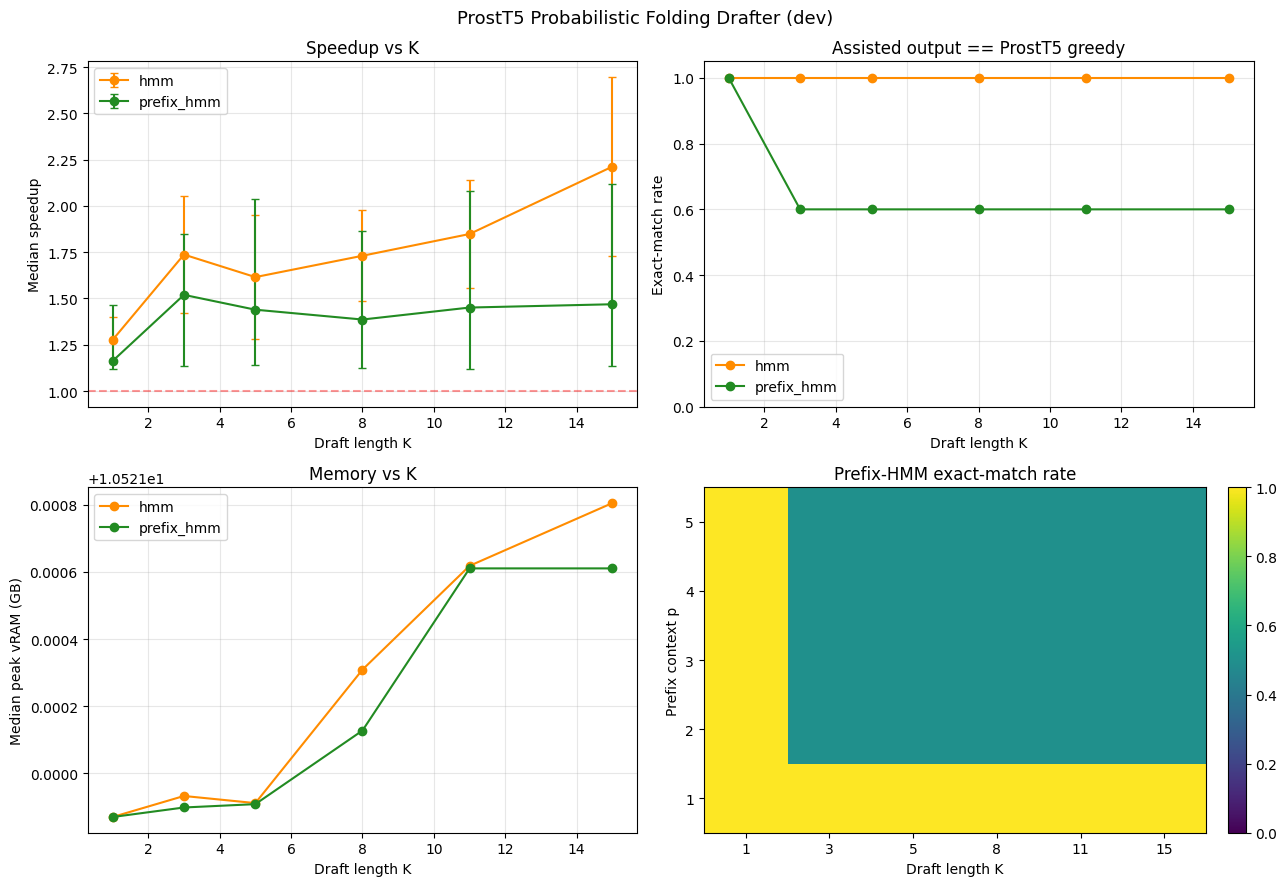

Saved plot to /content/Speculative-Decoding-ProstT5/prostT5/results/prostT5_probabilistic_drafter_folding_dev/probabilistic_drafter_folding_plots.png


In [40]:
#@title Plot benchmark result summary. { display-mode: "form" }

import matplotlib.pyplot as plt

colors = {"hmm": "darkorange", "prefix_hmm": "forestgreen"}
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Speedup vs K
ax = axes[0, 0]
for drafter in ["hmm", "prefix_hmm"]:
    sub = plot_df[plot_df["drafter"] == drafter]
    by_k = sub.groupby("K")["speedup"].median()
    q1 = sub.groupby("K")["speedup"].quantile(0.25)
    q3 = sub.groupby("K")["speedup"].quantile(0.75)
    ax.errorbar(by_k.index, by_k.values, yerr=[by_k.values - q1.values, q3.values - by_k.values], fmt="o-", label=drafter, color=colors[drafter], capsize=3)
ax.axhline(1.0, color="red", linestyle="--", alpha=0.4)
ax.set_xlabel("Draft length K")
ax.set_ylabel("Median speedup")
ax.set_title("Speedup vs K")
ax.legend()
ax.grid(True, alpha=0.3)

# Exactness vs K
ax = axes[0, 1]
for drafter in ["hmm", "prefix_hmm"]:
    sub = plot_df[plot_df["drafter"] == drafter]
    exact = sub.groupby("K")["exact_match"].mean()
    ax.plot(exact.index, exact.values, "o-", label=drafter, color=colors[drafter])
ax.set_xlabel("Draft length K")
ax.set_ylabel("Exact-match rate")
ax.set_ylim(0, 1.05)
ax.set_title("Assisted output == ProstT5 greedy")
ax.legend()
ax.grid(True, alpha=0.3)

# Peak vRAM vs K
ax = axes[1, 0]
for drafter in ["hmm", "prefix_hmm"]:
    sub = plot_df[(plot_df["drafter"] == drafter) & plot_df["peak_vram_gb"].notna()]
    mem = sub.groupby("K")["peak_vram_gb"].median()
    ax.plot(mem.index, mem.values, "o-", label=drafter, color=colors[drafter])
ax.set_xlabel("Draft length K")
ax.set_ylabel("Median peak vRAM (GB)")
ax.set_title("Memory vs K")
ax.legend()
ax.grid(True, alpha=0.3)

# Prefix p/K heatmap
ax = axes[1, 1]
heat = prefix_hmm_df.pivot_table(index="p", columns="K", values="exact_match", aggfunc="mean")
im = ax.imshow(heat.values, aspect="auto", origin="lower", vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xlabel("Draft length K")
ax.set_ylabel("Prefix context p")
ax.set_title("Prefix-HMM exact-match rate")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"ProstT5 Probabilistic Folding Drafter ({MODE})", fontsize=13)
fig.tight_layout()
plot_path = RESULTS_DIR / "probabilistic_drafter_folding_plots.png"
fig.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved plot to {plot_path}")
